In [1]:
from paper_plotting import *
import warnings

warnings.filterwarnings("ignore")

%matplotlib widget

# import os
# from mpl_toolkits.axes_grid.inset_locator import inset_axes
# from matplotlib.ticker import ScalarFormatter

In [ ]:
pre, post, lnM, Mcrit, b = 3, 2, 0.7, 9.5, 0.005
fs, lw, skip = 12, 2, 3
lums = np.linspace(5,18,200)
ticks = [7.0,7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0,11.5,12.0]
init = 0.1
fig = plt.figure(figsize=(22,8))
for z in [1.0,1.5,2.0]:

    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(lnM)
    qlf.get_Mbh(Mcrit, approx_local=True)
    qlf.get_dNdlnL(lums, [pre, post])

    sigs = qlf.Mdot_mu_sig[:,1] #std on MbhdotX distributions
    MbhdotX = np.e**qlf.Mdot_mu_sig[:,0]/(3.17098e-8*2e33) #solar mass per year w/ X model
    Ms = qlf.StellBins #stellar mass in solar mass
    lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
    prei = qlf.pre
    posti = qlf.post
    slopes = qlf.slopes
    Mloc = Ms[np.argmin(np.abs(slopes[posti]-0.95))]

    cmape = plt.cm.Blues
    norme = matplotlib.colors.Normalize(vmin=min(Ms)-1, vmax=Mcrit)
    cmapg = plt.cm.Greens
    normg = matplotlib.colors.Normalize(vmin=Mcrit-1, vmax=Mloc)
    cmapl = plt.cm.Reds
    norml = matplotlib.colors.Normalize(vmin=Mloc-1, vmax=max(Ms))

    ax = fig.add_axes([init, 0.55, 0.2, 0.35])
    ax.set_ylabel('Probability',fontsize=fs)
    ax.set_xlabel(r'$\eta$',fontsize=fs)
    ax.set_xscale('log')
    ax.set_title('z = '+str(z))
    x = np.linspace(-24, 5, 200)
    count0 = 0
    masses0 = []
    for mass, s, m in zip(Ms[::skip], sigs[::skip], lneta[::skip]):
        y = ( 1/np.sqrt(2.0 * np.pi * s**2.0) ) * np.exp( -(x - m)**2.0 / (2.0 * s**2) )
        if not y.any():
            count0 += 1
            masses0.append(mass)
        else:
            if mass < Mcrit:
                ax.plot(np.e**x,y,color=cmape(norme(mass)),lw=0.25)
            elif mass > Mloc:
                ax.plot(np.e**x,y,color=cmapl(norml(mass)),lw=0.25)
            else:
                ax.plot(np.e**x,y,color=cmapg(normg(mass)),lw=0.25)
    print('Skipped '+str(count0)+' mass bins for having all 0 eta values.')
    if count0 != 0:
        print(masses0[0], masses0[-1])
    
    axl = fig.add_axes([init+.205, 0.55+0.245, 0.01, 0.1])
    axg = fig.add_axes([init+.205, 0.55+0.125, 0.01, 0.1])
    axe = fig.add_axes([init+.205, 0.55+0.005, 0.01, 0.1])
    sm = plt.cm.ScalarMappable(cmap=cmape, norm=norme)
    sm.set_array([])
    fig.colorbar(sm, cax = axe, ticks = ticks)
    sm = plt.cm.ScalarMappable(cmap=cmapg, norm=normg)
    sm.set_array([])
    fig.colorbar(sm, cax = axg, label=r'$\log_{10} M_* (M_\odot)$', ticks = ticks)
    sm = plt.cm.ScalarMappable(cmap=cmapl, norm=norml)
    sm.set_array([])
    fig.colorbar(sm, cax = axl, ticks = ticks)
    init += 0.3

init = 0.1
for z in [3.6,4.8,6.0]:
    
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(lnM)
    qlf.get_Mbh(Mcrit, approx_local=True)
    qlf.get_dNdlnL(lums, [pre, post])

    sigs = qlf.Mdot_mu_sig[:,1] #std on MbhdotX distributions
    MbhdotX = np.e**qlf.Mdot_mu_sig[:,0]/(3.17098e-8*2e33) #solar mass per year w/ X model
    Ms = qlf.StellBins #stellar mass in solar mass
    lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
    prei = qlf.pre
    posti = qlf.post
    slopes = qlf.slopes
    Mloc = Ms[np.argmin(np.abs(slopes[posti]-0.95))]

    cmape = plt.cm.Blues
    norme = matplotlib.colors.Normalize(vmin=min(Ms)-1, vmax=Mcrit)
    cmapg = plt.cm.Greens
    normg = matplotlib.colors.Normalize(vmin=Mcrit-1, vmax=Mloc)
    cmapl = plt.cm.Reds
    norml = matplotlib.colors.Normalize(vmin=Mloc-1, vmax=max(Ms))
    
    ax = fig.add_axes([init,0.1,0.2,0.35])
    ax.set_ylabel('Probability',fontsize=fs)
    ax.set_xlabel(r'$\eta$',fontsize=fs)
    ax.set_xscale('log')
    ax.set_title('z = '+str(z))
    count0 = 0
    masses0 = []
    for mass, s, m in zip(Ms[::skip], sigs[::skip], lneta[::skip]):
        y = ( 1/np.sqrt(2.0 * np.pi * s**2.0) ) * np.exp( -(x - m)**2.0 / (2.0 * s**2) )
        if not y.any():
            count0 += 1
            masses0.append(mass)
        else:
            if mass < Mcrit:
                ax.plot(np.e**x,y,color=cmape(norme(mass)),lw=0.25)
            elif mass > Mloc:
                ax.plot(np.e**x,y,color=cmapl(norml(mass)),lw=0.25)
            else:
                ax.plot(np.e**x,y,color=cmapg(normg(mass)),lw=0.25)
    print('Skipped '+str(count0)+' mass bins for having all 0 eta values.')
    if count0 != 0:
        print(masses0[0], masses0[-1])
        
    axl = fig.add_axes([init+.205, 0.1+0.245, 0.01, 0.1])
    axg = fig.add_axes([init+.205, 0.1+0.125, 0.01, 0.1])
    axe = fig.add_axes([init+.205, 0.1+0.005, 0.01, 0.1])
    sm = plt.cm.ScalarMappable(cmap=cmape, norm=norme)
    sm.set_array([])
    fig.colorbar(sm, cax = axe, ticks = ticks)
    sm = plt.cm.ScalarMappable(cmap=cmapg, norm=normg)
    sm.set_array([])
    fig.colorbar(sm, cax = axg, label=r'$\log_{10} M_* (M_\odot)$', ticks = ticks)
    sm = plt.cm.ScalarMappable(cmap=cmapl, norm=norml)
    sm.set_array([])
    fig.colorbar(sm, cax = axl, ticks = ticks)  
    init += 0.3

# plt.tight_layout()
# plt.savefig('plots/paper-plots/eta_vs_sm-varyz_v2.2.pdf')

In [75]:
#### ASSUMING LAMBDA_SMBH = ETA

duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal = []
zl = []
zh = []
ml = []
mh = []
per = []
el = []
eh = []

for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1]))
        zh.append(float(s[2]))
        ml.append(float(s[3]))
        mh.append(float(s[4]))
        per.append(float(s[5]))
        el.append(float(s[6]))
        eh.append(float(s[7].split("\n")[0]))
        

yerr = np.zeros([2,len(el)])
yerr[0,:] = el
yerr[1,:] = eh

from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']

pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 10, 0.005
lums = np.linspace(5,18,200)

fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(16,8),sharey = True,sharex=True)
axes = [ax1, ax1, ax2, ax2, ax3, ax3]

for M, c, ax in zip(np.array(mass)+0.25,colors,axes):
    duty = []
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(lnM)
        qlf.get_Mbh(Mcrit, approx_local=True)
        qlf.get_dNdlnL(lums, [pre, post])

        lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
        sigs = qlf.Mdot_mu_sig[:,1] 
        lnstar = qlf.StellBins
        x = np.linspace(-25, 2, 2000)
        ind = np.argmin(np.abs(lnstar - M))
        y = ( 1/np.sqrt(2.0 * np.pi * sigs[ind]**2.0) ) * np.exp( -(x - lneta[ind])**2.0 / (2.0 * sigs[ind]**2) )
        duty.append(np.trapz(y[np.e**x>=0.01], x=x[np.e**x>=0.01])*100)
    ax.plot(ztot,duty ,c=c)



for i, c,ax in zip(mass,colors,axes):
    ind = np.where(np.array(ml) == i)[0]
    z = (np.array(zl)[ind]+np.array(zh)[ind])/2
    dut = np.array(per)[ind]
    err = np.array(yerr)[:,ind]
    
    ax.errorbar(z, dut, yerr = err, fmt='o-', color = c)

ax1.text(1.5,1, r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', color='navy',fontsize=14)
ax1.text(1.5,.7, r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', color='lightblue',fontsize=14)
ax2.text(1.5,12, r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0', color='teal',fontsize=14)
ax2.text(1.5,8, r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', color='gold',fontsize=14)
ax3.text(1.5,5, r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', color='brown',fontsize=14)
ax3.text(1.5,3, r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5', color='red',fontsize=14)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle \% $f(\eta > 0.01)$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

ax1.set_xlim([0, 4])
ax1.set_ylim([0, 100])
# ax1.set_yticks([0,1,10,100])

# ax1.xaxis.set_major_formatter(ScalarFormatter())

fig.savefig('plots/paper-plots/duty_cycle_varyzandmstar_v3.pdf')


FigureCanvasNbAgg()

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/axes/_base.py:3449: UserWarning: Attempted to set non-positive ylimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive ylimits for log-scale axis; '


In [74]:
#### ASSUMING LAMBDA_SMBH = ETA

duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,8),sharey = True,sharex=True)
axes = [ax1, ax1, ax2, ax2]

from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

colors = ['teal', 'gold', 'brown', 'r']
for c,ax in zip(colors,axes):
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for i in duty_arid.readlines():
        s = i.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    yerr = np.zeros([2,len(yerrup)])
    yerr[0,:] = yerrdown
    yerr[1,:] = yerrup
    duty_arid.close()

    ax.errorbar(x, y, yerr=yerr, fmt='o-', color = c, label='Arid+2017 II')
    ax.set_ylim([-2,0.5])
    
###########

mass = [9.5,10.0,10.5,11.0]
# mass = [[9.5,10.0],[10.0,10.5],[10.5,11.0],[11.0,11.5]]
ztot = [0.3,0.75,1.25,1.75,2.25,2.75,3.5]
pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 10, 0.005
lums = np.linspace(5,18,200)
    
for M, c, ax in zip(np.array(mass)+0.25,colors,axes):
    
    aveeta = []
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(lnM)
        qlf.get_Mbh(Mcrit, approx_local=True)
        qlf.get_dNdlnL(lums, [pre, post])
        
        lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
        sigs = qlf.Mdot_mu_sig[:,1]
        ind = np.argmin(np.abs(qlf.StellBins - M))
        
        x = np.linspace(-25, 2, 2000)
        y = ( 1/np.sqrt(2.0 * np.pi * sigs[ind]**2.0) ) * np.exp( -(x - lneta[ind])**2.0 / (2.0 * sigs[ind]**2) )
        duty = np.trapz(y[np.e**x>=0.01], x=x[np.e**x>=0.01])
        
        aveeta.append(np.log10(np.sum(y[np.e**x>=0.01]*np.e**x[np.e**x>=0.01]*(x[1]-x[0]))/duty))
        
        
    
    print(aveeta)
    ax.plot(ztot, aveeta ,c=c, label='kink model')

###########
    
ax1.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax1.text(1.,-1.5, r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0', color='teal',fontsize=14)
ax1.text(1.,-1.75, r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', color='gold',fontsize=14)
ax2.text(1.,.25, r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', color='brown',fontsize=14)
ax2.text(1.,0, r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5', color='red',fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc ='lower right')
plt.savefig('plots/paper-plots/aveBHAR_varyzandmstar_v2.pdf')

FigureCanvasNbAgg()

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


[-0.9691191055261387, -0.8760560267455478, -0.8155166644217394, -0.7781513578308569, -0.7640401278439757, -0.7633645331659022, -0.769016361613332]
[-0.8875858702347044, -0.7458878916195841, -0.6499625639221883, -0.5845433017509829, -0.5598865910891739, -0.5554159338721137, -0.5646982138756511]
[-1.0849552163609117, -0.9371796121688836, -0.8164440536262123, -0.723276261447854, -0.6781324021096851, -0.6646899879478809, -0.6672618556573416]
[-1.204636229310609, -1.0937374784994693, -0.9621228162351402, -0.8465176025335198, -0.7766503880702382, -0.7574775456735526, -0.7494755006360582]


In [69]:
##### USING THEIR FORMULA EXACTLY

duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal = []
zl = []
zh = []
ml = []
mh = []
per = []
el = []
eh = []

for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1]))
        zh.append(float(s[2]))
        ml.append(float(s[3]))
        mh.append(float(s[4]))
        per.append(float(s[5]))
        el.append(float(s[6]))
        eh.append(float(s[7].split("\n")[0]))
        

yerr = np.zeros([2,len(el)])
yerr[0,:] = el
yerr[1,:] = eh

from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']

pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 10, 0.005
lums = np.linspace(0.5,18,300) #log10 of solar luminosities


%matplotlib widget
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,8))

for M, c in zip(np.array(mass)+0.25,colors):#,axes):
    duty = []
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(lnM)
        qlf.get_Mbh(Mcrit, approx_local=True)
        qlf.get_dNdlnL(lums, [pre, post])
        
        Mdot = np.e**qlf.Mdot_mu_sig[:,3]
        mu_Mdot = qlf.Mdot_mu_sig[:,0]
        sig_Mdot = qlf.Mdot_mu_sig[:,1]
        lnstar = qlf.StellBins
        star = 10**lnstar
        
        lnLbol = np.log(10**lums*3.83e33) #log of erg/s
        muLbol = mu_Mdot + np.log(0.1 * (2.99e10)**2) #log of erg/s
        mulambda = muLbol - np.log(1.3e38*0.002*(10**M)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**M)) #log dimensionless
        
        ind = np.argmin(np.abs(lnstar - M))
        y = ( 1/np.sqrt(2.0 * np.pi * sig_Mdot[ind]**2.0) ) * np.exp( -(lnlambda - mulambda[ind])**2.0 / (2.0 * sig_Mdot[ind]**2) )
        ax2.plot(lnlambda, y, lw=0.5, c=c)
        duty.append(np.trapz(y[np.e**lnlambda>=0.01], x=lnlambda[np.e**lnlambda>=0.01])*100)
    ax1.plot(ztot,duty ,c=c)


labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

for i, c, l in zip(mass, colors, labels):
    ind = np.where(np.array(ml) == i)[0]
    z = (np.array(zl)[ind]+np.array(zh)[ind])/2
    dut = np.array(per)[ind]
    err = np.array(yerr)[:,ind]
    
    ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle \% $f(\eta > 0.01)$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax1.legend()

ax1.set_yscale('log')

ax1.set_xlim([0, 4])
ax1.set_ylim([0, 100])
ax2.set_xlabel(r'$\ln\lambda_{sBHAR}$',fontsize=18)
ax2.set_ylabel('Probability',fontsize=18)

fig.savefig('plots/paper-plots/duty_cycle_varyzandmstar_noeta_assump.pdf')


FigureCanvasNbAgg()

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/axes/_base.py:3449: UserWarning: Attempted to set non-positive ylimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive ylimits for log-scale axis; '


In [56]:
##### USING THEIR FORMULA EXACTLY

duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,8),sharey = True,sharex=True)
axes = [ax1, ax1, ax2, ax2]

from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

colors = ['teal', 'gold', 'brown', 'r']
for c,ax in zip(colors,axes):
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for i in duty_arid.readlines():
        s = i.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    yerr = np.zeros([2,len(yerrup)])
    yerr[0,:] = yerrdown
    yerr[1,:] = yerrup
    duty_arid.close()

    ax.errorbar(x, y, yerr=yerr, fmt='o-', color = c, label='Arid+2017 II')
    ax.set_ylim([-2,0.5])
    
###########

mass = [9.5,10.0,10.5,11.0]
# mass = [[9.5,10.0],[10.0,10.5],[10.5,11.0],[11.0,11.5]]
ztot = [0.3,0.75,1.25,1.75,2.25,2.75,3.5]
pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 9.5, 0.005
lums = np.linspace(5,18,200)
    
for M, c, ax in zip(np.array(mass)+0.25,colors,axes):
    
    aveeta = []
    for z in ztot:

        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(lnM)
        qlf.get_Mbh(Mcrit, approx_local=True)
        qlf.get_dNdlnL(lums, [pre, post])
        
        Mdot = np.e**qlf.Mdot_mu_sig[:,3]
        mu_Mdot = qlf.Mdot_mu_sig[:,0]
        sig_Mdot = qlf.Mdot_mu_sig[:,1]
        lnstar = qlf.StellBins
        star = 10**lnstar
        
        lnLbol = np.log(10**lums*3.83e33) #log of erg/s
        muLbol = mu_Mdot + np.log(0.1 * (2.99e10)**2) #log of erg/s
        mulambda = muLbol - np.log(1.3e38*0.002*(10**M)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**M)) #log dimensionless
        
        ind = np.argmin(np.abs(lnstar - M))
        y = ( 1/np.sqrt(2.0 * np.pi * sig_Mdot[ind]**2.0) ) * np.exp( -(lnlambda - mulambda[ind])**2.0 / (2.0 * sig_Mdot[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01], x=lnlambda[np.e**lnlambda>=0.01])
        
        aveeta.append(np.log10(np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0]))/duty))
        
        
    print(aveeta)
    ax1.plot(ztot, aveeta ,c=c, label='kink model')

###########
    
ax1.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax1.text(1.,-1.5, r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0', color='teal',fontsize=14)
ax1.text(1.,-1.75, r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', color='gold',fontsize=14)
ax2.text(1.,.25, r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', color='brown',fontsize=14)
ax2.text(1.,0, r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5', color='red',fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc ='lower right')
plt.savefig('plots/paper-plots/aveBHAR_varyzandmstar_noeta_assump.pdf')

FigureCanvasNbAgg()

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


[-0.644237656850009, -0.4262285211756937, -0.27073355644964986, -0.16926207933738657, -0.1298362904270962, -0.1279334581710812, -0.14380897615479665]
[-0.8850885980499661, -0.643371671926705, -0.45391765881682783, -0.31142587918009107, -0.254737221213272, -0.24427780016272174, -0.26593188081192437]
[-1.0082447321483248, -0.7957383926762909, -0.5976057727106773, -0.427795634758899, -0.3397735421751342, -0.3128042113494364, -0.3179915434459842]
[-1.1293145945751262, -0.9880643263820941, -0.7995932073378754, -0.6129267313225937, -0.4895791368803444, -0.45426131969103833, -0.43932886020341216]


In [46]:
####### USING THEIR DEFINITION EXACTLY ##########

from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,8))
fig.suptitle('Without $\lambda_{sBHAR} = \eta$ Assumption')
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']


duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
        per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

yerr = np.zeros([2,len(el)])
yerr[0,:], yerr[1,:] = el, eh

mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))

pre, post, SIG_lnMs, Ms_crit, b = 4, 3.25, 0.7, 10, 0.005

L = np.linspace(5,18,200) #log10 of solar luminosities

count = 0
for Ms, c in zip(np.array(mass)+0.25, colors):
    
    DUTY = []
    aveETA = []
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, approx_local=True)
        qlf.get_dNdlnL(L, [pre, post])
        
        MdotBH = np.e**qlf.Mdot_mu_sig[:,3]
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        
        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        
        ind = np.argmin(np.abs(lnMs - Ms))
        
        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01], x=lnlambda[np.e**lnlambda>=0.01])
        
        DUTY.append(duty*100)
        aveETA.append(np.log10(np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0]))/duty))
    
    ax1.plot(ztot, DUTY ,c=c)
    if count >= 2:
        ax2.plot(ztot, aveETA ,c=c,label = str(Ms))
    
    count+=1
    

for i, c, l in zip(mass, colors, labels):
    ind = np.where(np.array(ml) == i)[0]
    z = (np.array(zl)[ind]+np.array(zh)[ind])/2
    dut = np.array(per)[ind]
    err = np.array(yerr)[:,ind]
    
    ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)
    
    
for c in ['teal', 'gold', 'brown', 'r']:
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for i in duty_arid.readlines():
        s = i.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    yerr = np.zeros([2,len(yerrup)])
    yerr[0,:] = yerrdown
    yerr[1,:] = yerrup
    duty_arid.close()

    ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c)  
    
    

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle \% $f(\lambda_{sBHAR} > 0.01)$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax1.legend()

ax1.set_yscale('log')
ax1.set_xlim([0, 4])
ax1.set_ylim([0, 100])
    
ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.set_ylim([-2,0.5])

# plt.savefig('plots/paper-plots/aveBHAR_DUTY_varymstarz_noasump')


FigureCanvasNbAgg()

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh) #g/s
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/axes/_base.py:3449: UserWarning: Attempted to set non-positive ylimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive ylimits for log-scale axis; '


(-2, 0.5)

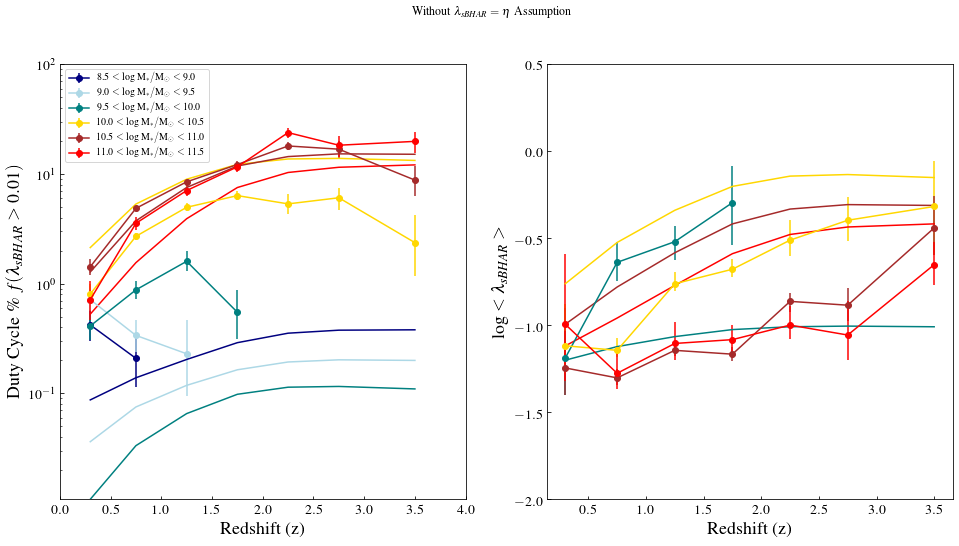

In [22]:
####### USING THEIR DEFINITION EXACTLY ##########
from functions_notfuckedup import *
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,8))
fig.suptitle('Without $\lambda_{sBHAR} = \eta$ Assumption')
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']


duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
        per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

yerr = np.zeros([2,len(el)])
yerr[0,:], yerr[1,:] = el, eh

mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))

pre, post, SIG_lnMs, Ms_crit, b = 4, 3.25, 0.7, 10, 0.005

L = np.linspace(5,18,200) #log10 of solar luminosities

count = 0

DUTY_tot = np.zeros((len(mass),len(ztot)))
aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

def dut_eta(Ms, ind):
    MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
    lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

    y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
    duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
    aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])
    
    return duty, aveeta

zcount = 0
for z in ztot:
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(Ms_crit, approx_local=True)
    qlf.get_dNdlnL(L, [pre, post])
    
    MdotBH = np.e**qlf.Mdot_mu_sig[:,3]
    MU_MdotBH = qlf.Mdot_mu_sig[:,0]
    SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
    lnMs = qlf.StellBins
    dNdlnMstar = qlf.dNdlnMstar
    
    lnLbol = np.log(10**L*3.83e33) #log of erg/s
    MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s
    
    Mcount = 0
    for Ms in mass:
        inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
        lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
        h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
        for i in inds:
            dut, eta = dut_eta(lnMs[i], i)
            DUTY_tot[Mcount,zcount] += dut*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] += eta*h
        if Mcount >= 2:
            aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
        DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
        Mcount += 1
    zcount += 1
    
pcount = 0
for i, c in zip(range(0,len(mass)), colors):
    ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
    if pcount >= 2:
        ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
    pcount+=1
    

for i, c, l in zip(mass, colors, labels):
    ind = np.where(np.array(ml) == i)[0]
    z = (np.array(zl)[ind]+np.array(zh)[ind])/2
    dut = np.array(per)[ind]
    err = np.array(yerr)[:,ind]
    
    ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)
    
    
for c in ['teal', 'gold', 'brown', 'r']:
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for i in duty_arid.readlines():
        s = i.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    yerr = np.zeros([2,len(yerrup)])
    yerr[0,:] = yerrdown
    yerr[1,:] = yerrup
    duty_arid.close()

    ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c)  
    
    

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle \% $f(\lambda_{sBHAR} > 0.01)$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax1.legend()

ax1.set_yscale('log')
ax1.set_xlim([0, 4])
ax1.set_ylim([0, 100])
    
ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.set_ylim([-2,0.5])

plt.savefig('plots/paper-plots/integrate_weight_aveBHAR_DUTY_varymstarz_noasump')


In [83]:
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)
# %matplotlib widget

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,8))
fig.suptitle('Without $\lambda_{sBHAR} = \eta$ Assumption')
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']


duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
        per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

yerr = np.zeros([2,len(el)])
yerr[0,:], yerr[1,:] = el, eh

mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))

pre, post, SIG_lnMs, Ms_crit, b = 4, 3.25, 0.7, 10, 0.005

L = np.linspace(5,18,200) #log10 of solar luminosities

for sig, ls in zip([3.5,4,4.5],['dashed','dotted','dashdot']):
    linecount = 0
    count = 0
    for Ms, c in zip(np.array(mass)+0.25, colors):

        DUTY = []
        aveETA = []
        for z in ztot:
            qlf = QLF(z, b)
            qlf.get_dNdlnMstar(SIG_lnMs)
            qlf.get_Mbh(Ms_crit, approx_local=True)
            qlf.get_dNdlnL(L, [sig, post])

            MdotBH = np.e**qlf.Mdot_mu_sig[:,3]
            MU_MdotBH = qlf.Mdot_mu_sig[:,0]
            SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
            lnMs = qlf.StellBins

            lnLbol = np.log(10**L*3.83e33) #log of erg/s
            MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s
            MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
            lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless

            ind = np.argmin(np.abs(lnMs - Ms))

            y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
            duty = np.trapz(y[np.e**lnlambda>=0.01], x=lnlambda[np.e**lnlambda>=0.01])

            DUTY.append(duty*100)
            aveETA.append(np.log10(np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0]))/duty))

        if count >= 2:
            if linecount == 0:
                ax2.plot(ztot, aveETA ,c='k',label = 'Pre-Disk Sigma = '+str(sig), linestyle=ls)
                linecount += 1
            ax2.plot(ztot, aveETA ,c=c, linestyle=ls)
            
        ax1.plot(ztot, DUTY ,c=c, linestyle=ls)
        
        count+=1
    

for i, c, l in zip(mass, colors, labels):
    ind = np.where(np.array(ml) == i)[0]
    z = (np.array(zl)[ind]+np.array(zh)[ind])/2
    dut = np.array(per)[ind]
    err = np.array(yerr)[:,ind]
    
    ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)
    
    
for c in ['teal', 'gold', 'brown', 'r']:
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for i in duty_arid.readlines():
        s = i.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    yerr = np.zeros([2,len(yerrup)])
    yerr[0,:] = yerrdown
    yerr[1,:] = yerrup
    duty_arid.close()

    ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c)  
    
    

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle \% $f(\lambda_{sBHAR} > 0.01)$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax1.legend()

ax1.set_yscale('log')
ax1.set_xlim([0, 4])
ax1.set_ylim([0, 100])
    
ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.set_ylim([-2,0.5])
ax2.legend()

plt.savefig('plots/paper-plots/3predisksig_aveBHAR_DUTY_varymstarz_noasump')


FigureCanvasNbAgg()

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh) #g/s
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/axes/_base.py:3449: UserWarning: Attempted to set non-positive ylimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive ylimits for log-scale axis; '
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/font_manager.py:1328: UserWarning: findfont: Font family ['serif'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotl

In [19]:
#### ASSUMING LAMBDA_SMBH = ETA

duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal = []
zl = []
zh = []
ml = []
mh = []
per = []
el = []
eh = []

for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1]))
        zh.append(float(s[2]))
        ml.append(float(s[3]))
        mh.append(float(s[4]))
        per.append(float(s[5]))
        el.append(float(s[6]))
        eh.append(float(s[7].split("\n")[0]))
        

yerr = np.zeros([2,len(el)])
yerr[0,:] = el
yerr[1,:] = eh

from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 10, 0.005
lums = np.linspace(5,18,200)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,8))
fig.suptitle('With $\lambda_{sBHAR} = \eta$ Assumption')

count = 0
for M, c in zip(np.array(mass)+0.25,colors):
    duty = []
    aveETA = []
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(lnM)
        qlf.get_Mbh(Mcrit, approx_local=True)
        qlf.get_dNdlnL(lums, [pre, post])

        lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
        sigs = qlf.Mdot_mu_sig[:,1] 
        lnstar = qlf.StellBins
        x = np.linspace(-25, 2, 2000)
        ind = np.argmin(np.abs(lnstar - M))
        y = ( 1/np.sqrt(2.0 * np.pi * sigs[ind]**2.0) ) * np.exp( -(x - lneta[ind])**2.0 / (2.0 * sigs[ind]**2) )
        DUT = np.trapz(y[np.e**x>=0.01], x=x[np.e**x>=0.01])
        duty.append(DUT*100)
        aveETA.append(np.log10(np.sum(y[np.e**x>=0.01]*np.e**x[np.e**x>=0.01]*(x[1]-x[0]))/DUT))
        
    ax1.plot(ztot,duty ,c=c)
        
    if count >= 2:
        ax2.plot(ztot,aveETA,c=c)
        
    count+=1     
    

for i, c, l in zip(mass,colors,labels):
    ind = np.where(np.array(ml) == i)[0]
    z = (np.array(zl)[ind]+np.array(zh)[ind])/2
    dut = np.array(per)[ind]
    err = np.array(yerr)[:,ind]
    
    ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c,label = l)
    
    
for c in ['teal', 'gold', 'brown', 'r']:
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for i in duty_arid.readlines():
        s = i.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    yerr = np.zeros([2,len(yerrup)])
    yerr[0,:] = yerrdown
    yerr[1,:] = yerrup
    duty_arid.close()

    ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle \% $f(\eta = \lambda_{sBHAR} > 0.01)$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax1.legend()
ax1.set_yscale('log')
ax1.set_xlim([0, 4])
ax1.set_ylim([0, 100])


ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\eta = \lambda_{sBHAR}>$',fontsize=18)
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.set_ylim([-2,0.5])
ax2.legend()


# fig.savefig('plots/paper-plots/aveBHAR_DUTY_varyzandmstar_wasump')


FigureCanvasNbAgg()

IndexError: index 2 is out of bounds for axis 1 with size 2